# LING 498 Hackathon — Prompt 12

## WordNet semantic domains (lexnames) in a corpus

**Category:** Semantics

**Question:** Does the distribution of WordNet lexnames (semantic domains) look Zipf-like in a corpus sample?

- **Data:** Brown tokens + WordNet (nltk.corpus.wordnet as wn).
- **Items to Count:** Lexname of the first synset for each noun/adjective (intentionally imperfect).

**Steps**
- POS-tag; keep nouns (NN*) and/or adjectives (JJ*); alphabetic only.
- Optional: lemmatize.
- Get synsets for each word; if any, take synsets[0].lexname().
- Run Zipf report/plot.
- Interpret: what this distribution means—and what it doesn’t—given polysemy and sense choice.

**Deliverable:** Top lexnames + 2 limitations about sense assignment + one “next step” to improve validity.

In [34]:
import re
import nltk
from nltk import FreqDist
from nltk.corpus import brown
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Run these once if needed
# nltk.download("brown")
# nltk.download("wordnet")
# nltk.download("omw-1.4")
# nltk.download("averaged_perceptron_tagger_eng")

In [ ]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Lexname Types: {len(ranked)} | Lexname Tokens: {sum(c for _, c in ranked)}")
    print("Top lexnames:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [21]:
# load corpus
tokens = brown.words()

In [ ]:
# remove tokens that are only punctuation
words = []

for token in tokens:
    if not re.fullmatch(r"\W+", token):
        words.append(token)

print("Number of non-punctuation tokens:", len(words))
print(words[:10])

Number of non-punctuation tokens: 1013319
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of']


In [36]:
# pos tagging
tagged_words = nltk.pos_tag(words)
print(tagged_words[:10])

[('The', 'DT'), ('Fulton', 'NNP'), ('County', 'NNP'), ('Grand', 'NNP'), ('Jury', 'NNP'), ('said', 'VBD'), ('Friday', 'NNP'), ('an', 'DT'), ('investigation', 'NN'), ('of', 'IN')]


In [37]:
# keep only nouns (NN*) and adjectives (JJ*); alphabetic only
filtered_words = []

for word, tag in tagged_words:

    if not word.isalpha():
        continue
    
    if tag.startswith("NN") or tag.startswith("JJ"):
        filtered_words.append((word.lower(), tag))

print("Number of noun/adjective tokens:", len(filtered_words))
print(filtered_words[:10])

# Note: proper nouns are included if they receive an NNP/NNPS tag.

Number of noun/adjective tokens: 354114
[('fulton', 'NNP'), ('county', 'NNP'), ('grand', 'NNP'), ('jury', 'NNP'), ('friday', 'NNP'), ('investigation', 'NN'), ('recent', 'JJ'), ('primary', 'JJ'), ('election', 'NN'), ('evidence', 'NN')]


In [38]:
# lemmatize (base form)
lemmatizer = WordNetLemmatizer()

lemmatized_words = []

for word, tag in filtered_words:

    # Use the correct WordNet POS for lemmatization
    if tag.startswith("NN"):
        lemma = lemmatizer.lemmatize(word, pos="n")
    else:
        lemma = lemmatizer.lemmatize(word, pos="a")

    lemmatized_words.append((lemma, tag))

print("Number of lemmatized noun/adjective tokens:", len(lemmatized_words))
print(lemmatized_words[:10])

Number of lemmatized noun/adjective tokens: 354114
[('fulton', 'NNP'), ('county', 'NNP'), ('grand', 'NNP'), ('jury', 'NNP'), ('friday', 'NNP'), ('investigation', 'NN'), ('recent', 'JJ'), ('primary', 'JJ'), ('election', 'NN'), ('evidence', 'NN')]


In [39]:
# extract WordNet lexnames
lexnames = []

for word, tag in lemmatized_words:

    if tag.startswith("NN"):
        synsets = wn.synsets(word, pos=wn.NOUN)
    else:
        synsets = wn.synsets(word, pos=wn.ADJ)

    if len(synsets) > 0:
        first_synset = synsets[0]
        lexname = first_synset.lexname()
        lexnames.append(lexname)

print("Number of Lexname tokens:", len(lexnames))
print(lexnames[:10])

Number of Lexname tokens: 320568
['noun.person', 'noun.location', 'noun.quantity', 'noun.group', 'noun.time', 'noun.cognition', 'adj.all', 'adj.all', 'noun.act', 'noun.cognition']



=== WordNet Lexname Types ===
Tag Types: 29 | Tags: 320568
Top tags:
 1. adj.all                                  66773
 2. noun.person                              33476
 3. noun.artifact                            25073
 4. noun.act                                 22546
 5. noun.communication                       21173
 6. noun.cognition                           19263
 7. noun.group                               18775
 8. noun.location                            15534
 9. noun.attribute                           13503
10. noun.time                                11564
11. noun.state                               10307
12. adj.pert                                 7509
13. noun.event                               7164
14. noun.quantity                            6181
15. noun.body                                6093

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.997
 f1/(3*f3) = 0.888
 f1/(4*f4) = 0.74
 f1/(5*f5) = 0.631


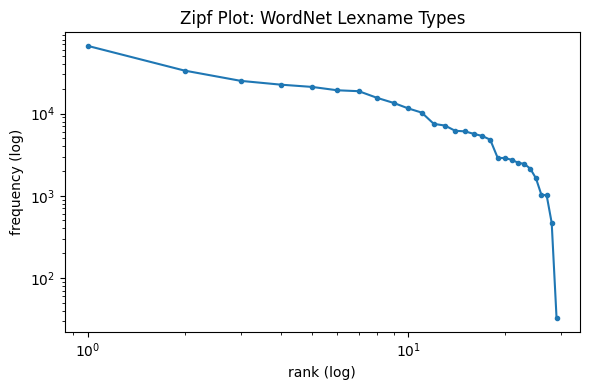

In [40]:
ranked_lexnames = zipf_quick_report(lexnames, title="WordNet Lexname Types")
zipf_plot(ranked_lexnames, title="Zipf Plot: WordNet Lexname Types")